# Neural responses to natural images versus artificial gratings in the mouse visual cortex

**Group members:** Bassam Hajjawi, Dhruv Sood, Saaim Farhan

## Overview

We compared how V1 neurons in mouse visual cortex respond to two kinds of visual stimuli: natural photographs and drifting gratings. Using the Allen Brain Observatory dataset, we tracked the same neurons under both stimuli across 5 imaging containers in primary visual cortex (VISp). For each neuron we measured the average response size, how repeatable that response was across trials, and how selective the neuron was across stimuli. We then compared the three measurements between the two stimulus types with paired t-tests.

## I. Experimental Question and Hypothesis

**Question:** Do neurons in the mouse primary visual cortex (V1 / VISp) respond more strongly to natural images than to artificial drifting gratings?

Specifically, we measured three variables per neuron: mean response magnitude, response reliability across repeated presentations, and lifetime sparseness across stimuli.


**Hypothesis:** We expected natural scenes to drive stronger, more reliable, and more sparse responses than drifting gratings. Mouse visual cortex evolved to process natural visual input (de Vries et al., 2020), and prior work shows that natural scenes recruit V1 more efficiently than artificial stimuli (Yoshida & Ohki, 2020; Froudarakis et al., 2019). If V1 is tuned for natural image statistics, the same neurons should fire harder to scenes than to gratings, give similar responses on each repeat (high reliability), and be selective about which scenes they respond to (high sparseness).

## II. Background 

The primary visual cortex is the first area of the brain that is responsible for processing visual information. From experiments done in labs using artificial stimuli, researchers have gathered data on orientation selectivity and spatial frequency tuning and more. However, these patterns only reflect a portion of the natural environment. Real world scenes incorporate varied textures, structures, and diverse patterns, which can result in activating neural circuits in a manner that differs from controlled lab environments. A study by de Vries et al. (2020) has shown that the visual system is adapted to process the structure of natural environments efficiently, suggesting a natural scene is crucial to the functionalization and organization of V1. Examining the differences of the V1 neurons will lead to a better understanding of real world neural processing and how accurately our traditional experiments capture the same effect. 

Recent studies have shown that natural environments have revealed aspects of V1 function that aren’t captured by artificial drifting gratings. For example, research by Yoshida and Okhi (2020) has demonstrated that a small group of neurons can effectively encode natural images. Furthermore, Froudarakis et al. (2019) found that natural scenes lead to a broader feature selectivity compared to the standard methods. Using data from the Allen Brain Observatory and the previous sources mentioned, it’s fairly suggestive that natural images are able to produce more meaningful activity in V1. Our aim is to compare the responses and ultimately figure out if studying in more realistic contexts is crucial to record complex and true capabilities of the primary visual cortex. 


**Primary sources**
- Yoshida, T., & Ohki, K. (2020). *Natural images are reliably represented by sparse and variable populations of neurons in visual cortex.* Nature Communications, 11(1), 872.
- Froudarakis, E. et al. (2019). *Population code in mouse V1 facilitates readout of natural scenes through increased sparseness.* Nature Neuroscience, 22, 1418–1428.
- de Vries, S. E. J. et al. (2020). *A large-scale standardized physiological survey reveals functional organization of the mouse visual cortex.* Nature Neuroscience, 23(1), 138–151.

## III. Approach

**Dataset:** The Allen Brain Observatory Visual Coding dataset was collected by the Allen Institute for Brain Science, where head-fixed mice passively viewed visual stimuli while two-photon calcium imaging recorded neural activity. A fluorescent calcium indicator (GCaMP) was used so that when neurons fire, they glow brighter, allowing hundreds of neurons to be recorded simultaneously.

We used 5 experiment containers from primary visual cortex (VISp), each representing one mouse. The two sessions we analyzed were drifting gratings (8 orientations × 5 temporal frequencies = 40 conditions) and natural scenes (118 grayscale photographs). After matching neurons across both sessions, our final sample was 588 neurons.

**The key variables extracted per neuron were:**
- ΔF/F fluorescence traces: the raw measure of neural activity over time
- Stimulus tables: timestamps for when each stimulus appeared
- Mean response magnitude: average ΔF/F in 500ms after stimulus minus 500ms baseline before it
- Response reliability: how consistently a neuron responds to the same stimulus across repeated trials. Measured by splitting trials into two halves, averaging each, and correlating them. Higher correlation means more reliable.
- Lifetime sparseness: how selectively a neuron responds across the full set of stimuli

## 1. Setup

Install AllenSDK (Colab) and import the libraries we need. The first cell only needs to run once per environment.

In [4]:
try:
    import allensdk
    print('allensdk imported')
except ImportError as e:
    !pip install allensdk

allensdk imported


In [5]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from allensdk.core.brain_observatory_cache import BrainObservatoryCache
import allensdk.brain_observatory.stimulus_info as stim_info

np.random.seed(0)
plt.rcParams['figure.dpi'] = 110

## 2. Initialize the cache and select VISp experiments

The Allen Brain Observatory splits each experiment container into three imaging sessions (A, B, C). Drifting gratings live in session A and natural scenes live in session B, so we collect both for the same set of containers.

In [18]:
# connect to the Allen Brain Observatory dataset
boc = BrainObservatoryCache(manifest_file='boc/manifest.json')

# get all experiment containers that recorded from primary visual cortex (VISp)
# each container represents one mouse, with multiple sessions (A, B, C) inside it.
visp_containers = boc.get_experiment_containers(targeted_structures=['VISp'])
container_ids = [c['id'] for c in visp_containers]
print(f'Found {len(container_ids)} VISp experiment containers')

# experiments that used drifting gratings stimulus
dg_experiments = boc.get_ophys_experiments(
    experiment_container_ids=container_ids,
    stimuli=[stim_info.DRIFTING_GRATINGS],
)

# experiments that used natural scenes stimulus
ns_experiments = boc.get_ophys_experiments(
    experiment_container_ids=container_ids,
    stimuli=[stim_info.NATURAL_SCENES],
)

# make dictionaries: container_id to experiment_id for drifting gratings (session A) and natural scenes (session B)
dg_by_container = {exp['experiment_container_id']: exp['id'] for exp in dg_experiments}
ns_by_container = {exp['experiment_container_id']: exp['id'] for exp in ns_experiments}

# only keep containers that have both a drifting gratings and natural scenes session
paired_containers = sorted(set(dg_by_container) & set(ns_by_container))
print(f'Containers with both DG and NS sessions: {len(paired_containers)}')

Found 216 VISp experiment containers
Containers with both DG and NS sessions: 144


We pick a small subset of containers (5 containers) to keep download/compute time reasonable.

In [21]:
#select 5 paired containers
selected_containers = paired_containers[:5]
selected_containers

[511498742, 511507650, 511507811, 511509529, 511510650]

## 3. Helper functions: response window, reliability, sparseness

For each stimulus presentation we take the mean ΔF/F (measure of neural activity in calcium imaging) in the first 500 ms after onset and subtract a 500 ms pre-stimulus baseline. From the resulting trial × stimulus response matrix we compute per-neuron summary statistics.

In [22]:
RESPONSE_WINDOW_S = 0.5  # how long after stimulus to measure
BASELINE_WINDOW_S = 0.5  # how long before stimulus to measure as baseline

def seconds_to_frames(timestamps, seconds): #Convert seconds to number of frames based on recording speed.
    frame_duration = np.median(np.diff(timestamps))
    num_frames = max(int(round(seconds / frame_duration)), 1)
    return num_frames


def get_trial_responses(dff, timestamps, stim_table, stim_id_col): #compute how much each neuron responded in each trial.
    # response = average activity after stimulus - average activity before stimulus.
    # returns response array (n_cells x n_trials) and stimulus id for each trial.

    response_frames = seconds_to_frames(timestamps, RESPONSE_WINDOW_S)
    baseline_frames = seconds_to_frames(timestamps, BASELINE_WINDOW_S)

    n_cells = dff.shape[0]
    n_trials = len(stim_table)

    # initialize with NaN so we can skip bad trials
    all_responses = np.full((n_cells, n_trials), np.nan)
    all_stim_ids = np.full(n_trials, -1)

    for trial_num, row in enumerate(stim_table.itertuples(index=False)):
        stim_start = int(row.start)

        # skip trial if it goes out of bounds
        if stim_start - baseline_frames < 0 or stim_start + response_frames > dff.shape[1]:
            continue

        activity_after = dff[:, stim_start : stim_start + response_frames].mean(axis=1)
        activity_before = dff[:, stim_start - baseline_frames : stim_start].mean(axis=1)

        all_responses[:, trial_num] = activity_after - activity_before
        all_stim_ids[trial_num] = getattr(row, stim_id_col)

    # remove trials that were skipped
    valid_trials = all_stim_ids >= 0
    return all_responses[:, valid_trials], all_stim_ids[valid_trials]


def get_mean_response_per_image(responses, stim_ids): #average all trials of the same image together.
    unique_stims = np.unique(stim_ids)
    mean_responses = np.zeros((responses.shape[0], len(unique_stims)))

    for j, stim in enumerate(unique_stims):
        trials_for_this_stim = stim_ids == stim
        mean_responses[:, j] = np.nanmean(responses[:, trials_for_this_stim], axis=1)

    return mean_responses #returns array of shape (n_cells, n_images).


def get_reliability(responses, stim_ids): # measure how consistently each neuron responds to the same image across trials.
    # split trials into two halves, correlate the responses. Higher = more reliable.
    # returns one reliability value per neuron.
    n_cells = responses.shape[0]
    reliability_scores = np.full(n_cells, np.nan)

    unique_stims = np.unique(stim_ids)

    # need at least 2 images and 2 repeats of each to do a split
    if len(unique_stims) < 2:
        return reliability_scores

    min_repeats = min((stim_ids == s).sum() for s in unique_stims)
    if min_repeats < 2:
        return reliability_scores

    half = min_repeats // 2

    # build two halves of trials for each image
    half_a = np.zeros((n_cells, len(unique_stims)))
    half_b = np.zeros((n_cells, len(unique_stims)))

    for j, stim in enumerate(unique_stims):
        trial_indices = np.where(stim_ids == stim)[0]
        np.random.shuffle(trial_indices)
        half_a[:, j] = np.nanmean(responses[:, trial_indices[:half]], axis=1)
        half_b[:, j] = np.nanmean(responses[:, trial_indices[half : 2 * half]], axis=1)

    # correlate the two halves for each neuron
    for cell in range(n_cells):
        a = half_a[cell]
        b = half_b[cell]
        if np.all(np.isfinite(a)) and np.all(np.isfinite(b)):
            if np.std(a) > 0 and np.std(b) > 0:
                reliability_scores[cell] = np.corrcoef(a, b)[0, 1]

    return reliability_scores


def get_lifetime_sparseness(mean_responses): # measure how selective each neuron is across images (Treves-Rolls formula).
    # near 1 = responds to very few images (selective). near 0 = responds equally to all images (not selective).
    # returns one sparseness value per neuron.
    r = np.clip(mean_responses, 0, None)
    n_images = r.shape[1]

    sum_of_responses = r.sum(axis=1)
    sum_of_squares = (r ** 2).sum(axis=1)

    numerator = (sum_of_responses ** 2) / n_images

    with np.errstate(invalid='ignore', divide='ignore'):
        sparseness = 1 - (numerator / sum_of_squares)
        sparseness = sparseness / (1 - 1 / n_images)

    return sparseness

The Treves-Rolls sparseness formula is:

$$s = \frac{1 - \frac{(\sum r_i)^2}{n \sum r_i^2}}{1 - \frac{1}{n}}$$

Where $r_i$ is the neuron's mean response to each stimulus and $n$ is the number of stimuli.

It compares how peaked the response distribution is. If a neuron responds equally to everything, sparseness is 0. If it only responds to one image, sparseness is 1.

## 4. Load each container and compute metrics for both stimulus types

We only keep neurons whose `cell_specimen_id` appears in both sessions, so every comparison below is paired within neuron.

In [10]:
records = []

for cid in selected_containers:
    print(f'\n=== container {cid} ===')

    # load experiment data for this container
    try:
        dg_data = boc.get_ophys_experiment_data(ophys_experiment_id=dg_by_container[cid])
        ns_data = boc.get_ophys_experiment_data(ophys_experiment_id=ns_by_container[cid])
    except Exception as e:
        print(f'  skipped: {e}')
        continue

    # get dff traces and timestamps for each experiment
    dg_timestamps, dg_dff = dg_data.get_dff_traces()
    ns_timestamps, ns_dff = ns_data.get_dff_traces()

    # get the cell ids recorded in each experiment
    dg_cell_ids = np.array(dg_data.get_cell_specimen_ids())
    ns_cell_ids = np.array(ns_data.get_cell_specimen_ids())

    # only keep cells that appear in both experiments
    shared_cell_ids = np.intersect1d(dg_cell_ids, ns_cell_ids)
    if len(shared_cell_ids) == 0:
        print('  no shared cells, skipping')
        continue

    # find the row index of each shared cell in each experiment's dff array
    dg_row_indices = np.array([np.where(dg_cell_ids == c)[0][0] for c in shared_cell_ids])
    ns_row_indices = np.array([np.where(ns_cell_ids == c)[0][0] for c in shared_cell_ids])

    # filter dff to only the shared cells
    dg_dff = dg_dff[dg_row_indices]
    ns_dff = ns_dff[ns_row_indices]

    print(f'  shared cells: {len(shared_cell_ids)}')

    # *drifting gratings stimulus table*
    dg_table = dg_data.get_stimulus_table('drifting_gratings')
    dg_table = dg_table.dropna(subset=['orientation', 'temporal_frequency']).copy()

    # each unique (orientation, temporal_frequency) combo gets its own stim_id number
    dg_table['stim_id'] = (
        dg_table['orientation'].astype(int).astype(str) + '_' +
        dg_table['temporal_frequency'].astype(str)
    )
    dg_table['stim_id'] = pd.Categorical(dg_table['stim_id']).codes

    # *natural scenes stimulus table*
    ns_table = ns_data.get_stimulus_table('natural_scenes')
    ns_table = ns_table[ns_table['frame'] >= 0].copy()  # drop blank/gray sweeps
    ns_table['stim_id'] = ns_table['frame'].astype(int)

    # compute trial-by-trial responses for each experiment
    dg_responses, dg_stim_ids = get_trial_responses(dg_dff, dg_timestamps, dg_table, 'stim_id')
    ns_responses, ns_stim_ids = get_trial_responses(ns_dff, ns_timestamps, ns_table, 'stim_id')

    if dg_responses.size == 0 or ns_responses.size == 0:
        print('  no usable trials, skipping')
        continue

    # average responses across trials for each stimulus
    dg_mean_per_stim = get_mean_response_per_image(dg_responses, dg_stim_ids)
    ns_mean_per_stim = get_mean_response_per_image(ns_responses, ns_stim_ids)

    # build a summary dataframe for this container. One row per neuron
    container_df = pd.DataFrame({
        'container_id':      cid,
        'cell_specimen_id':  shared_cell_ids,
        'dg_mean':           np.nanmean(dg_responses, axis=1),
        'ns_mean':           np.nanmean(ns_responses, axis=1),
        'dg_reliability':    get_reliability(dg_responses, dg_stim_ids),
        'ns_reliability':    get_reliability(ns_responses, ns_stim_ids),
        'dg_sparseness':     get_lifetime_sparseness(dg_mean_per_stim),
        'ns_sparseness':     get_lifetime_sparseness(ns_mean_per_stim),
    })

    records.append(container_df)

# combine all containers into one dataframe
if records:
    metrics = pd.concat(records, ignore_index=True)
else:
    metrics = pd.DataFrame()

print(f'\nTotal neurons in analysis: {len(metrics)}')
metrics.head()


=== container 511498742 ===
  shared cells: 131

=== container 511507650 ===
  shared cells: 91

=== container 511507811 ===
  shared cells: 98

=== container 511509529 ===
  shared cells: 158

=== container 511510650 ===
  shared cells: 114

Total neurons in analysis: 592


,container_id,cell_specimen_id,dg_mean,ns_mean,dg_reliability,ns_reliability,dg_sparseness,ns_sparseness
0,511498742,517397365,-0.002413,-0.000048,0.020650,0.534000,0.852867,0.893369
1,511498742,517397369,-0.002606,0.000070,0.097874,0.230306,0.866187,0.777501
2,511498742,517397373,-0.003207,0.000027,0.169664,0.098455,0.778110,0.784185
3,511498742,517397377,-0.002003,0.000058,0.330139,0.492836,0.803208,0.730987
4,511498742,517397381,-0.003032,0.000367,0.138558,0.513161,0.919415,0.829376


## 5. Compare distributions

Drop any neurons where a metric could not be computed (for example: zero variance) so the paired comparisons line up.

In [11]:
clean = metrics.dropna(subset=[
    'dg_mean', 'ns_mean',
    'dg_reliability', 'ns_reliability',
    'dg_sparseness', 'ns_sparseness',
]).reset_index(drop=True)
print(f'Neurons with complete metrics: {len(clean)}')
clean.describe()

Neurons with complete metrics: 588


,container_id,cell_specimen_id,dg_mean,ns_mean,dg_reliability,ns_reliability,dg_sparseness,ns_sparseness
count,5.880000e+02,5.880000e+02,588.000000,588.000000,588.000000,588.000000,588.000000,588.000000
mean,5.115068e+08,5.278822e+08,-0.000140,0.000095,0.158213,0.439157,0.745956,0.833561
std,4.430225e+03,2.499006e+07,0.012289,0.000240,0.230331,0.198290,0.142471,0.066166
min,5.114987e+08,5.173974e+08,-0.091862,-0.001210,-0.389129,-0.147113,0.320339,0.657021
25%,5.115076e+08,5.174063e+08,-0.003322,0.000025,0.011082,0.293971,0.658041,0.784412
50%,5.115078e+08,5.174092e+08,-0.000098,0.000078,0.131915,0.443344,0.766604,0.830207
75%,5.115095e+08,5.174199e+08,0.003029,0.000147,0.270179,0.575344,0.861080,0.883907
max,5.115106e+08,5.891537e+08,0.119965,0.001901,0.958212,0.867254,1.000000,0.980137


### 5a. Mean response magnitude

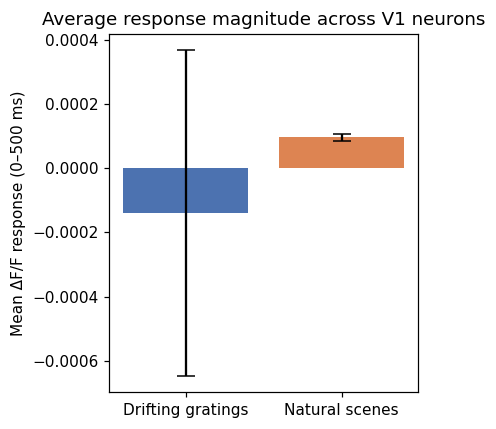

In [12]:
means = [clean['dg_mean'].mean(), clean['ns_mean'].mean()]
sems = [stats.sem(clean['dg_mean']), stats.sem(clean['ns_mean'])]
fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(['Drifting gratings', 'Natural scenes'], means, yerr=sems, capsize=6,
       color=['#4c72b0', '#dd8452'])
ax.set_ylabel('Mean ΔF/F response (0–500 ms)')
ax.set_title('Average response magnitude across V1 neurons')
plt.tight_layout()
plt.show()

On average, V1 neurons responded more strongly to natural scenes than drifting gratings. The natural scenes mean was slightly positive (≈0.000095 ΔF/F) with a very tight error bar, indicating a small but consistent response across neurons. The drifting gratings mean was slightly negative (≈-0.000140 ΔF/F), suggesting that on average neurons were weakly suppressed below baseline. The much larger standard deviation for drifting gratings (0.012 vs 0.000240) indicates high variability across neurons. Some neurons responded strongly while most did not, which makes sense since only neurons tuned to specific orientations and frequencies would be driven by that stimulus.

### 5b. Response reliability — paired scatter

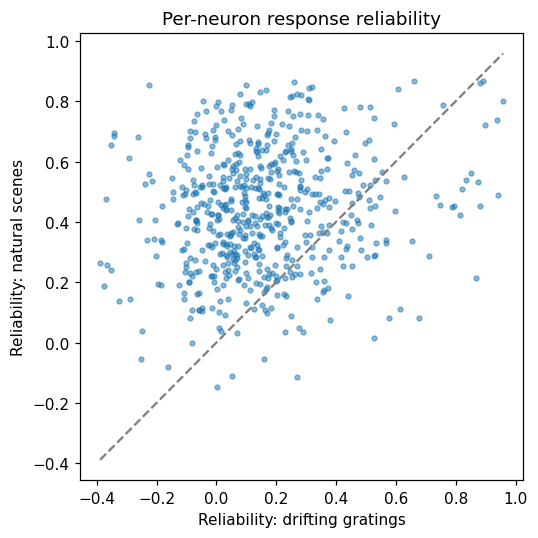

In [23]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(clean['dg_reliability'], clean['ns_reliability'], s=10, alpha=0.5)
lim = [min(clean['dg_reliability'].min(), clean['ns_reliability'].min()),
       max(clean['dg_reliability'].max(), clean['ns_reliability'].max())]
ax.plot(lim, lim, '--', color='gray')
ax.set_xlabel('Reliability: drifting gratings')
ax.set_ylabel('Reliability: natural scenes')
ax.set_title('Per-neuron response reliability')
plt.tight_layout()
plt.show()

Each dot is one neuron, with its drifting gratings reliability on the x-axis and natural scenes reliability on the y-axis. The dashed gray line is the diagonal (x = y). Dots above it mean that neuron was more reliable for natural scenes, dots below mean more reliable for gratings.

The majority of dots sit above the diagonal, meaning most neurons responded more consistently to natural scenes than to drifting gratings. This matches the summary stats, which show the mean reliability was 0.439 for natural scenes vs 0.158 for drifting gratings. There is still a positive correlation between the two, meaning neurons that were reliable for one stimulus tended to be somewhat reliable for the other as well, but the overall shift upward is clear.

### 5c. Lifetime sparseness

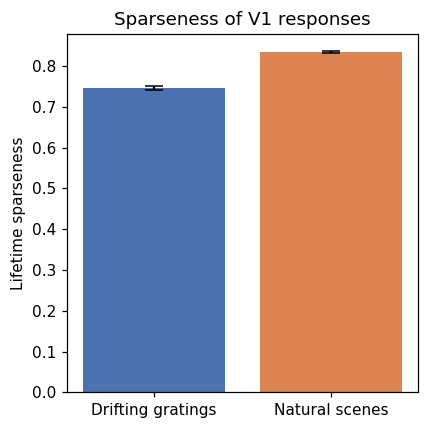

In [14]:
means = [clean['dg_sparseness'].mean(), clean['ns_sparseness'].mean()]
sems = [stats.sem(clean['dg_sparseness']), stats.sem(clean['ns_sparseness'])]
fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(['Drifting gratings', 'Natural scenes'], means, yerr=sems, capsize=6,
       color=['#4c72b0', '#dd8452'])
ax.set_ylabel('Lifetime sparseness')
ax.set_title('Sparseness of V1 responses')
plt.tight_layout()
plt.show()

Both stimulus types produced high sparseness values, meaning V1 neurons were selective in general, and they didn't respond equally to all stimuli. However, natural scenes (≈0.834) produced higher sparseness than drifting gratings (≈0.746), meaning neurons were even more selective about which natural images they responded to compared to which gratings they responded to. Both error bars are very tight, indicating this difference is consistent across neurons and not driven by a few outliers.

## 6. Statistical tests

Each neuron contributes a paired (drifting-grating, natural-scene) measurement, so we use paired t-tests for the three metrics.

In [15]:
def paired(metric):
    a = clean[f'dg_{metric}']
    b = clean[f'ns_{metric}']
    t, p = stats.ttest_rel(a, b)
    return {'metric': metric, 'dg_mean': a.mean(), 'ns_mean': b.mean(),
            't': t, 'p': p, 'n': len(a)}

results = pd.DataFrame([paired('mean'), paired('reliability'), paired('sparseness')])
results

,metric,dg_mean,ns_mean,t,p,n
0,mean,-0.000140,0.000095,-0.465534,6.417220e-01,588
1,reliability,0.158213,0.439157,-24.376056,3.428568e-91,588
2,sparseness,0.745956,0.833561,-12.989802,4.308432e-34,588


- **Mean response:** t = -0.47, p = 0.64. Not significant. Despite the means pointing in the right direction (DG negative, NS positive), the difference was not statistically significant.
- **Reliability:** t = -24.38, p < 0.001. Highly significant. Neurons were far more reliable for natural scenes (0.439) than drifting gratings (0.158). This is the strongest result in the analysis.
- **Sparseness:** t = -12.99, p < 0.001. Highly significant. Neurons were more selective for natural scenes (0.834) than drifting gratings (0.746).

## Conclusion & Discussion

### Results
Overall, two out of three predictions from our hypothesis were confirmed. Natural scenes drove more reliable and more selective responses than drifting gratings. However, the mean response magnitude difference was not statistically significant, meaning we cannot conclude that natural scenes drive stronger responses, just more consistent and more selective ones.

This supports the idea that V1 is better tuned for natural visual input, but the effect shows up in the *quality* of responses (reliability and selectivity) rather than the raw *strength*.

### Limitations
- **Small sample:** We only used 5 experiment containers (588 neurons). A larger sample would give more statistical power and more generalizable results.
- **Only one brain region:** We only looked at VISp. Natural scenes might have even stronger effects in other visual areas.
- **500ms response window:** We used a fixed 500ms window for all stimuli. Natural scenes and drifting gratings have different timings, so a single window might not capture the best response for both.


### Additional Experiments
- **Include more visual areas** to see if the natural scene advantage is stronger in higher cortical areas.
- **Try other stimulus types** like natural movies or scrambled versions of natural scenes to test what specific features of natural images drive the reliability effect.
- **Look at specific neuron subtypes** such as excitatory vs inhibitory neurons might show different reliability patterns for natural vs artificial stimuli.